In [19]:
# this is some set-up stuff i stole from HW2 to make things reproducible 
# and so i have an environment to reuse a bunch of my code


# If you are running in a fresh environment, uncomment to install dependencies:
#!pip -q install torch==2.8.0 torchvision==0.23.0 matplotlib==3.10.0 tqdm==4.67.3 scikit-learn==1.6.1 numpy==2.0.2
# here i've forced install to be the versions that match google colab and also my local env
# for reproducibility

import os
import platform
if platform.system() == "Windows":
    import ctypes
    from importlib.util import find_spec
    try:
        if (spec := find_spec("torch")) and spec.origin and os.path.exists(
            dll_path := os.path.join(os.path.dirname(spec.origin), "lib", "c10.dll")
        ):
            ctypes.CDLL(os.path.normpath(dll_path))
    except Exception:
        pass
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torchvision.models as models
import torchvision.transforms.v2 as transforms
from torch.utils.data import Dataset, DataLoader, random_split

print("torch:", torch.__version__)
device = "cpu"  # For fixed, reproducible results. (You may switch to "cuda" after you finish debugging.)
print("device:", device)

def set_seed(seed: int = 42):
    """Make results as reproducible as possible across runs."""
    import os, random
    import numpy as np
    import torch

    os.environ["PYTHONHASHSEED"] = str(seed)
    # If you later switch to CUDA and want maximal determinism:
    # os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic flags (safe on CPU; on GPU some ops may error if non-deterministic)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)

set_seed(42)

torch: 2.8.0+cpu
device: cpu


In [20]:
# i don't have a graphics card...
torch.cuda.is_available()

False

In [ ]:
# make custom dataset for train
import pandas as pd
import csv
from torchvision.io import read_image 

batch_size = 64
num_workers = 0
img_size = 384

# make annotations file for train dataset by walking thru directory
# and writing a csv w/ each image and what label folder they're in
with open("./out/train_labels.csv", mode="w", newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["ID","Label"])
    labels = os.listdir("./data/train")
    for i in range(len(labels)):
        for img in os.listdir(os.path.join("./data/train", labels[i])):
            writer.writerow([img, labels[i]])

# from intro to pytorch lecture slides
class CustomImageTrainData(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)
    
    def __getitem__(self, index):
        img_path = os.path.join(self.img_dir, f'{self.img_labels.iloc[index,1]}', self.img_labels.iloc[index,0])
        image = read_image(img_path)
        label = self.img_labels.iloc[index,1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

full_train_dataset = CustomImageTrainData("./out/train_labels.csv", "./data/train", 
    transform=transforms.Compose([
        transforms.ToImage(),
        transforms.Resize(size=(384, 384), antialias=True),
        transforms.RandomResizedCrop((img_size, img_size), antialias=True),
        transforms.RandomErasing(p=0.1),
        transforms.ToDtype(torch.float32, scale=True),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    target_transform=transforms.Compose([
        transforms.ToDtype(torch.float32)
    ])
)
print(len(full_train_dataset))


1079


971 108


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.4657085].


Feature batch shape: torch.Size([64, 3, 384, 384])
Labels batch shape: torch.Size([64])
Label: 79


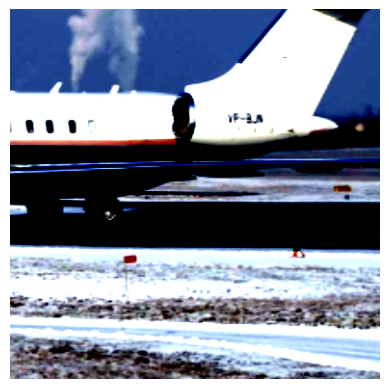

In [22]:
# split dataset and set up dataloaders for train/val, verify is working
import math

split_rate = 0.9

train_set, val_set = random_split(full_train_dataset, [math.floor(len(full_train_dataset)*split_rate), (len(full_train_dataset) - math.floor(len(full_train_dataset)*split_rate))])
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size)
print(len(train_set), len(val_set))


train_features, train_labels = next(iter(train_loader))
img = train_features[0].numpy().transpose(1, 2, 0)
label = train_labels[0]
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
print(f"Label: {label}")
plt.imshow(img)
plt.axis("off")
plt.show()


In [23]:
# set up model & some hyperparameters
dropout_rate = 0.2
model = models.efficientnet_v2_s(weights="EfficientNet_V2_S_Weights.IMAGENET1K_V1").to(device)

# replace classifier head w/ adjustable dropout rate
# to match new number of classifers (100)
# and add a softmax
model.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1280, 256),
    nn.ReLU(),
    nn.Dropout(dropout_rate, inplace=False),
    nn.Linear(256, 100),
    nn.Softmax(dim=1)
)

# freeze all features except classifier head right now
for param in model.features:
    param.requires_grad_(False)

# label smoothing 0.1 as per pytorch's improved training recipe
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [24]:
# eval function - ripped from hw 2
# Q3.2: Validation function
@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model and return (avg_loss, accuracy)."""
    # ========== YOUR CODE STARTS HERE ==========
    # TODO:
    # - Set model to evaluation mode
    # - Loop through batches without computing gradients
    # - Compute loss and accuracy
    # - Return average loss and accuracy
    model.eval()
    correct = 0
    running_loss = 0.0
    total = 0
    for _batch, (x, y) in enumerate(loader):
        pred = model(x)
        loss = criterion(pred, y)
        running_loss += loss.item()
        total += y.size(0)
        for i in range(pred.size(0)):
            _, predicted = torch.max(pred[i], 0)
            if predicted == y[i]:
                correct += 1
    avg_loss = running_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy
    # ========== YOUR CODE ENDS HERE ============

# try running on train loader right now to see what happens
avg_loss, accuracy = evaluate(model, val_loader)
print(avg_loss, accuracy)

4.605243444442749 0.009259259259259259


In [25]:
# now that is set up to use HW2 code, can use training functions
classifier_epochs = 15
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-3, weight_decay=2e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, classifier_epochs)

def train_one_epoch(model, loader):
    """Train for one epoch and return (avg_loss, accuracy)."""
    # ========== YOUR CODE STARTS HERE ==========
    # TODO:
    # - Set model to training mode
    # - Loop through batches in the loader
    # - For each batch:
    #   * Zero gradients
    #   * Forward pass
    #   * Compute loss
    #   * Backward pass
    #   * Optimizer step
    # - Track total loss and accuracy (IMPORTANT: get predicted labels and compare with targets)
    # - Return average loss and accuracy

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for _batch, (x, y) in enumerate(loader):
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        total += y.size(0)
        for i in range(pred.size(0)):
            _, predicted = torch.max(pred[i], 0)
            if predicted == y[i]:
                correct += 1
    train_loss = running_loss / len(loader)
    accuracy = correct / total
    return train_loss, accuracy
    # ========== YOUR CODE ENDS HERE ============

# Q3.3: Training loop with checkpointing
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_epoch = -1
ckpt_path = "./out/best_classifierhead_only.pt"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Loop through epochs
# - Each epoch: train, validate, log metrics
# - Track best validation accuracy and save checkpoint when improved
# - Print training and validation metrics each epoch
# - For checkpoint: save a dictionary containing keys `model_state_dict` and `epoch`
for i in range(classifier_epochs):
    print(f'Epoch {i}\n-----')
    print("Training...")
    train_loss, train_acc = train_one_epoch(model, train_loader)
    print("Validating...")
    val_loss, val_acc = evaluate(model, val_loader)
    scheduler.step()
    history["train_loss"].append(train_loss)
    history['train_acc'].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f'Train loss: {train_loss:.4f} Train acc.: {(train_acc*100):.2f}% Validation loss: {val_loss:.4f} Validation acc.: {(val_acc*100):.2f}%\n')
    if min(history["val_loss"]) == val_loss:
        torch.save({"model_state_dict": model.state_dict(), "epoch": i, "history": history}, ckpt_path)
best_val_loss = min(history["val_loss"])
best_epoch = history["val_loss"].index(best_val_loss)
# ========== YOUR CODE ENDS HERE ============

print("Best val loss:", best_val_loss, "at epoch", best_epoch)
print("Saved to:", ckpt_path)

Epoch 0
-----
Training...
Validating...
Train loss: 4.5555 Train acc.: 9.89% Validation loss: 4.4835 Validation acc.: 12.96%

Epoch 1
-----
Training...
Validating...
Train loss: 4.4298 Train acc.: 23.17% Validation loss: 4.4011 Validation acc.: 24.07%

Epoch 2
-----
Training...
Validating...
Train loss: 4.3754 Train acc.: 27.29% Validation loss: 4.3788 Validation acc.: 26.85%

Epoch 3
-----
Training...
Validating...
Train loss: 4.3413 Train acc.: 29.87% Validation loss: 4.3516 Validation acc.: 30.56%

Epoch 4
-----
Training...
Validating...
Train loss: 4.3523 Train acc.: 30.79% Validation loss: 4.3445 Validation acc.: 29.63%

Epoch 5
-----
Training...
Validating...
Train loss: 4.3168 Train acc.: 32.65% Validation loss: 4.3485 Validation acc.: 30.56%

Epoch 6
-----
Training...
Validating...
Train loss: 4.3203 Train acc.: 35.02% Validation loss: 4.3177 Validation acc.: 33.33%

Epoch 7
-----
Training...
Validating...
Train loss: 4.2965 Train acc.: 36.56% Validation loss: 4.3257 Validation

In [27]:
classifier_ckpt_path = "./out/best_classifierhead_only.pt"
classifier_ckpt = torch.load(classifier_ckpt_path)
model.load_state_dict(classifier_ckpt["model_state_dict"])
class_loss = []
class_acc = []

num_avg = 5

for i in range(num_avg):
    print(f"Evaluating x{i + 1}...")
    l, a = evaluate(model, val_loader)
    class_loss.append(l)
    class_acc.append(a)
    print(f"Loss: {l:.4f} Accuracy: {(a*100):.2f}%")

print(f"Classifier-only best loss: {min(class_loss):.4f} | Classifier-only best acc: {(max(class_acc)*100):.2f}%")
print(f"Classifier-only avg loss: {(sum(class_loss) / num_avg):.4f} | Classifier-only avg acc: {(sum(class_acc) * 100 / num_avg):.2f}%")

Evaluating x1...
Loss: 4.3243 Accuracy: 34.26%
Evaluating x2...
Loss: 4.3325 Accuracy: 31.48%
Evaluating x3...
Loss: 4.3475 Accuracy: 29.63%
Evaluating x4...
Loss: 4.3231 Accuracy: 32.41%
Evaluating x5...
Loss: 4.3351 Accuracy: 31.48%
Classifier-only best loss: 4.3231 | Classifier-only best acc: 34.26%
Classifier-only avg loss: 4.3325 | Classifier-only avg acc: 31.85%


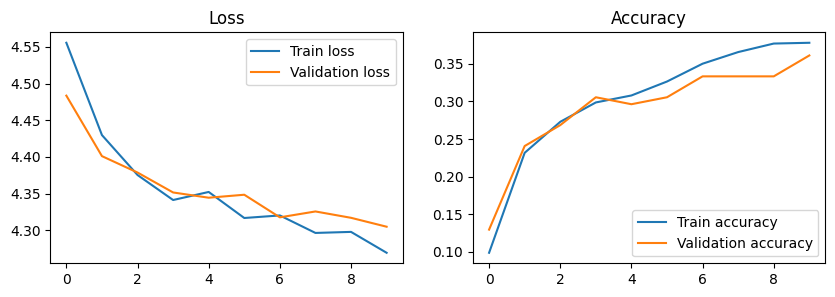

In [28]:
history = classifier_ckpt["history"]

# Q3.4: Plot curves
# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Create two plots: one for loss (train vs val), one for accuracy (train vs val)
# - Use the history dictionary to get the values
# - Add labels, legends, and display the plots

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train accuracy")
plt.plot(history["val_acc"], label="Validation accuracy")
plt.title("Accuracy")
plt.legend()

plt.show()
# ========== YOUR CODE ENDS HERE ============

In [41]:
# create dataset and dataloader for test images, no labels

with open("./out/test_list.csv", mode="w", newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["ID"])
    labels = os.listdir("./data/test")
    labels.sort(key=lambda x : int(x.split(".")[0]))
    for i in range(len(labels)):
         writer.writerow([labels[i]])

class CustomImageTestData(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)
    
    def __getitem__(self, index):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[index,0])
        image = read_image(img_path)
        if self.transform:
            image = self.transform(image)
        return image, self.img_labels.iloc[index,0]
    
test_dataset = CustomImageTestData("./out/test_list.csv", "./data/test", transform=transforms.Compose([
        transforms.ToImage(),
        transforms.Resize(size=(img_size, img_size), antialias=True),
        transforms.ToDtype(torch.float32, scale=True),
    ]))

test_loader = DataLoader(test_dataset, batch_size=batch_size)

print(len(test_dataset), len(test_loader))

1036 17


In [ ]:
# test eval function that writes to csv borrowed from HW2
@torch.no_grad()
def test_evaluate(model, loader):
    """Evaluate model and return (avg_loss, accuracy)."""
    # ========== YOUR CODE STARTS HERE ==========
    # TODO:
    # - Set model to evaluation mode
    # - Loop through batches without computing gradients
    # - Compute loss and accuracy
    # - Return average loss and accuracy
    model.eval()
    rows = []
    for _batch, (x, y) in enumerate(loader):
        pred = model(x)
        for i in range(pred.size(0)):
            _, predicted = torch.max(pred[i], 0)
            rows.append([y, predicted])
    return rows
    # ========== YOUR CODE ENDS HERE ============

sub_list = test_evaluate(model, test_loader)

with open("./out/submission.csv", mode="w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["ID","Label"])
    for row in sub_list:
        writer.writerow(row)

print("Wrote test evaluation to ./out/submission.csv")
